<a href="https://colab.research.google.com/github/ArjunBhakta/Data-Science-Cohort-20/blob/main/Project-1%20/TransactionGNB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: Transaction Success Prediction
Arjun Bhakta



This project looks at transaction data. One very important subset of performing data science on transaction data consists of binary classification problems such as: is a customer satisfied? Will a customer buy this product? Can a customer pay this loan?

In this project, we want to predict whether or not a future customer will make a transaction based on their transaction data.

The data provided has the same structure as real data typically available to solve this problem. The columns of the input variables have been anonymized, so there is no intuition available to help judge which variables might be more important, so all variables need to be considered equally.

The project should be done using the Gaussian Naive Bayes classification techniques as covered in class. In this directory is included a recommended "To Do" list for the
project.

The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv


In [1]:
# https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv

## Problem Definition

This project aims to predict whether a customer will make a transaction (target = 1) or not (target = 0) using anonymized transaction data. The dataset consists of multiple numerical predictor variables with no domain-specific labels, requiring all features to be treated equally.

The objective is to apply a Gaussian Naive Bayes (GNB) classification model, which assumes that predictor variables follow a normal distribution and are conditionally independent given the target class. The analysis will evaluate whether these assumptions are reasonably satisfied and assess the model’s ability to classify transactions accurately.


## Data Collection






---

###Load Python Packages

---




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
import math
import scipy.stats as stats


---

### Load transaction data from AWS S3.

---



In [3]:
df = pd.read_csv('https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv')

## Data Cleaning

1. If there are data cleaning issues, develop recommendations for how to deal with them.





---
### Examine the data

Examining the head of the data to get an initial understanding. Confirmed from the head that the columns of the input variables have been anonymized, so there is no intuition available to help judge which variables might be more **important**

---



In [4]:
df.head()
df.tail()

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,NaN,8.1795,NaN,NaN,...,NaN,-12.1108,NaN,10.7608,NaN,NaN,NaN,NaN,NaN,14.1690




---


###Determine the shape of the loaded Data

---






In [5]:
df.shape

(1050000, 104)



---
### Examining the data types of all columns. Confirmed features are float64 and target is binary
---




In [6]:
df.info()

# Uncomment for full verbose list printed out
# df.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 104 entries, Unnamed: 0 to var_100
dtypes: float64(102), int64(1), object(1)
memory usage: 833.1+ MB




---
###Printing percentage of null values in every column. Data shows entire columns missing as well as 82.85% null entries in other columns missing   across multiple features.
---



In [7]:
nan_percent = df.isna().mean() * 100
print(nan_percent)

Unnamed: 0      0.000000
ID_code         0.000000
target         82.857143
var_0          82.857143
var_1          82.857143
                 ...    
var_96        100.000000
var_97        100.000000
var_98        100.000000
var_99        100.000000
var_100        82.857143
Length: 104, dtype: float64




---


###Vizualize nulls in the data set. Intuitively shows that entire rows are missing as well as entire columns

---



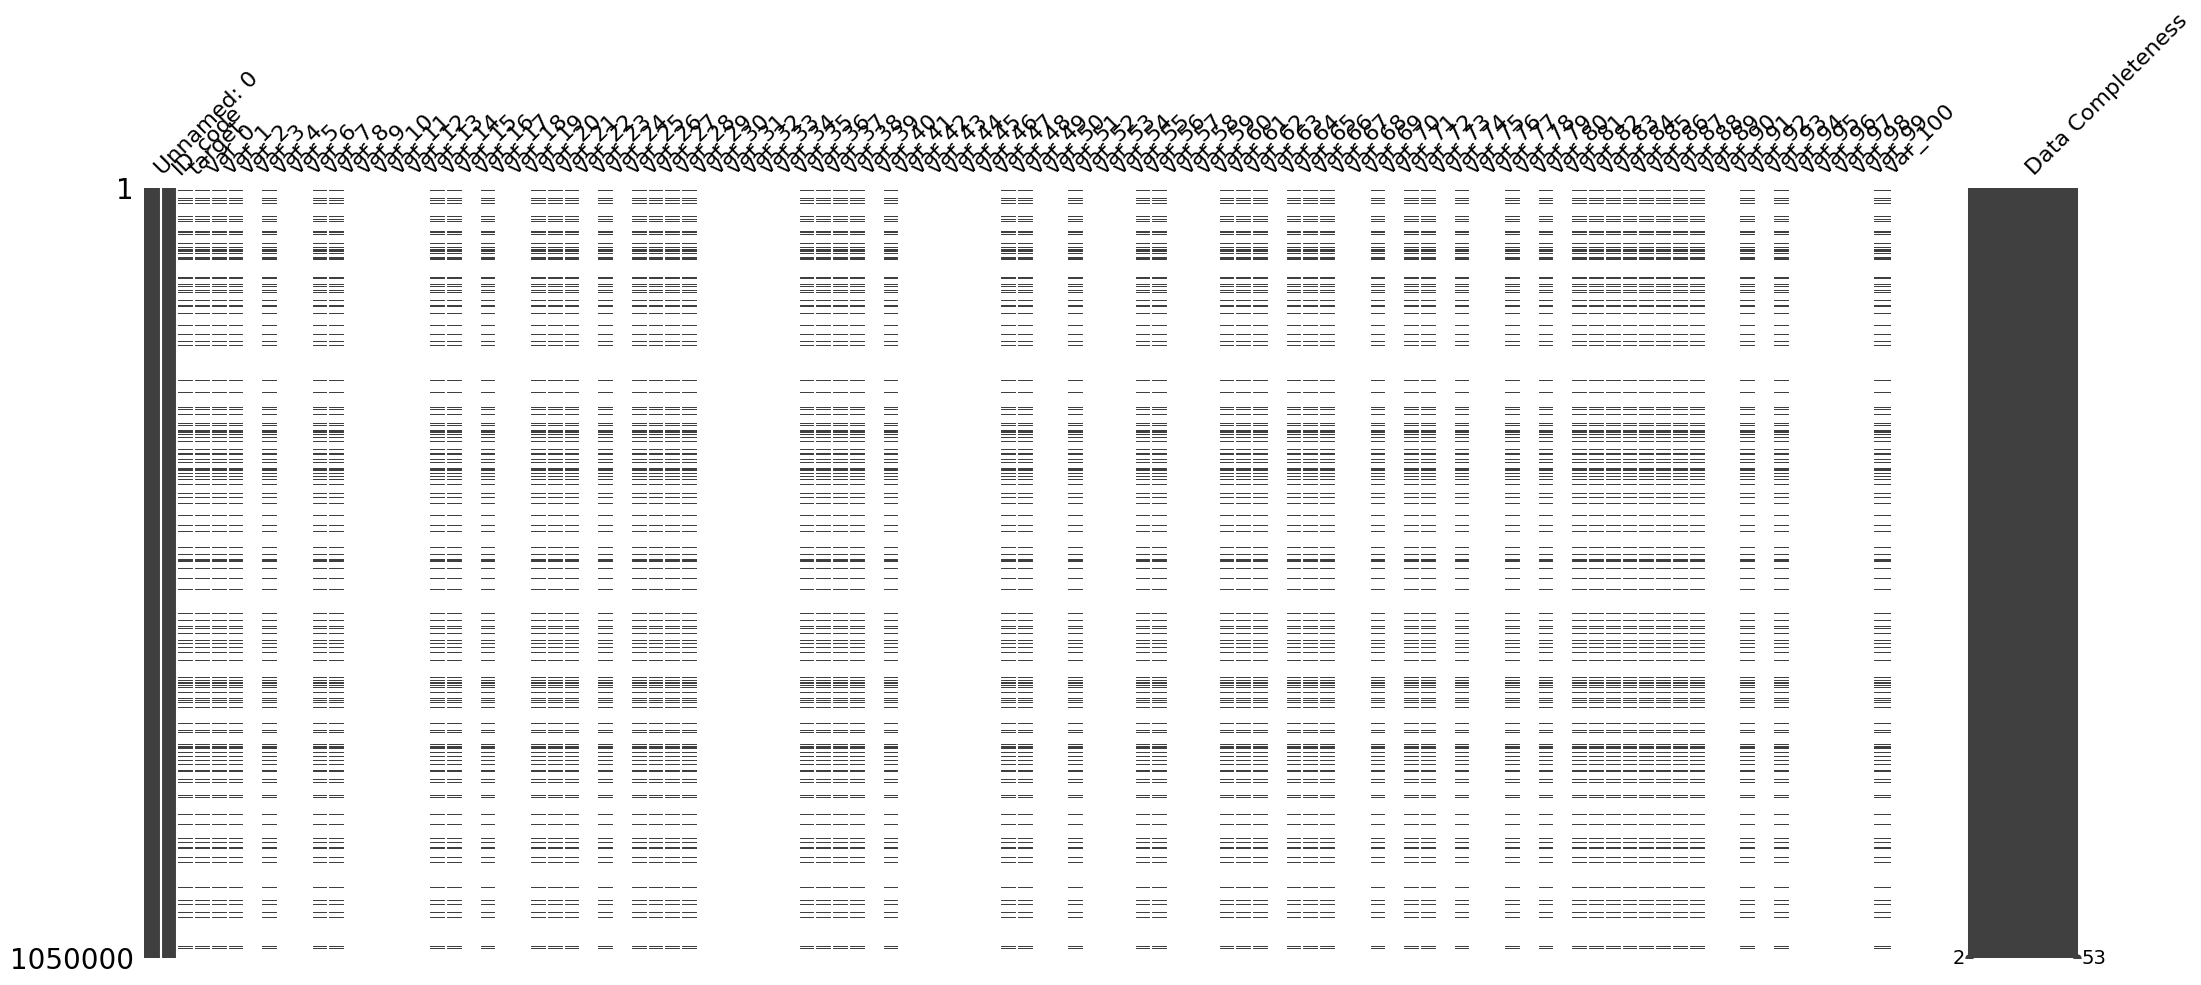

In [8]:
msno.matrix(df, labels=True)
plt.show()




---

### Dropping entire columns with 100% null values

---



In [9]:
df_cleaned = df.dropna(axis=1, how='all')
df_cleaned.shape

(1050000, 53)



---


###Vizualize after all empty 100% empty columns were dropped. Intuitively shows that entire rows are missing.

---



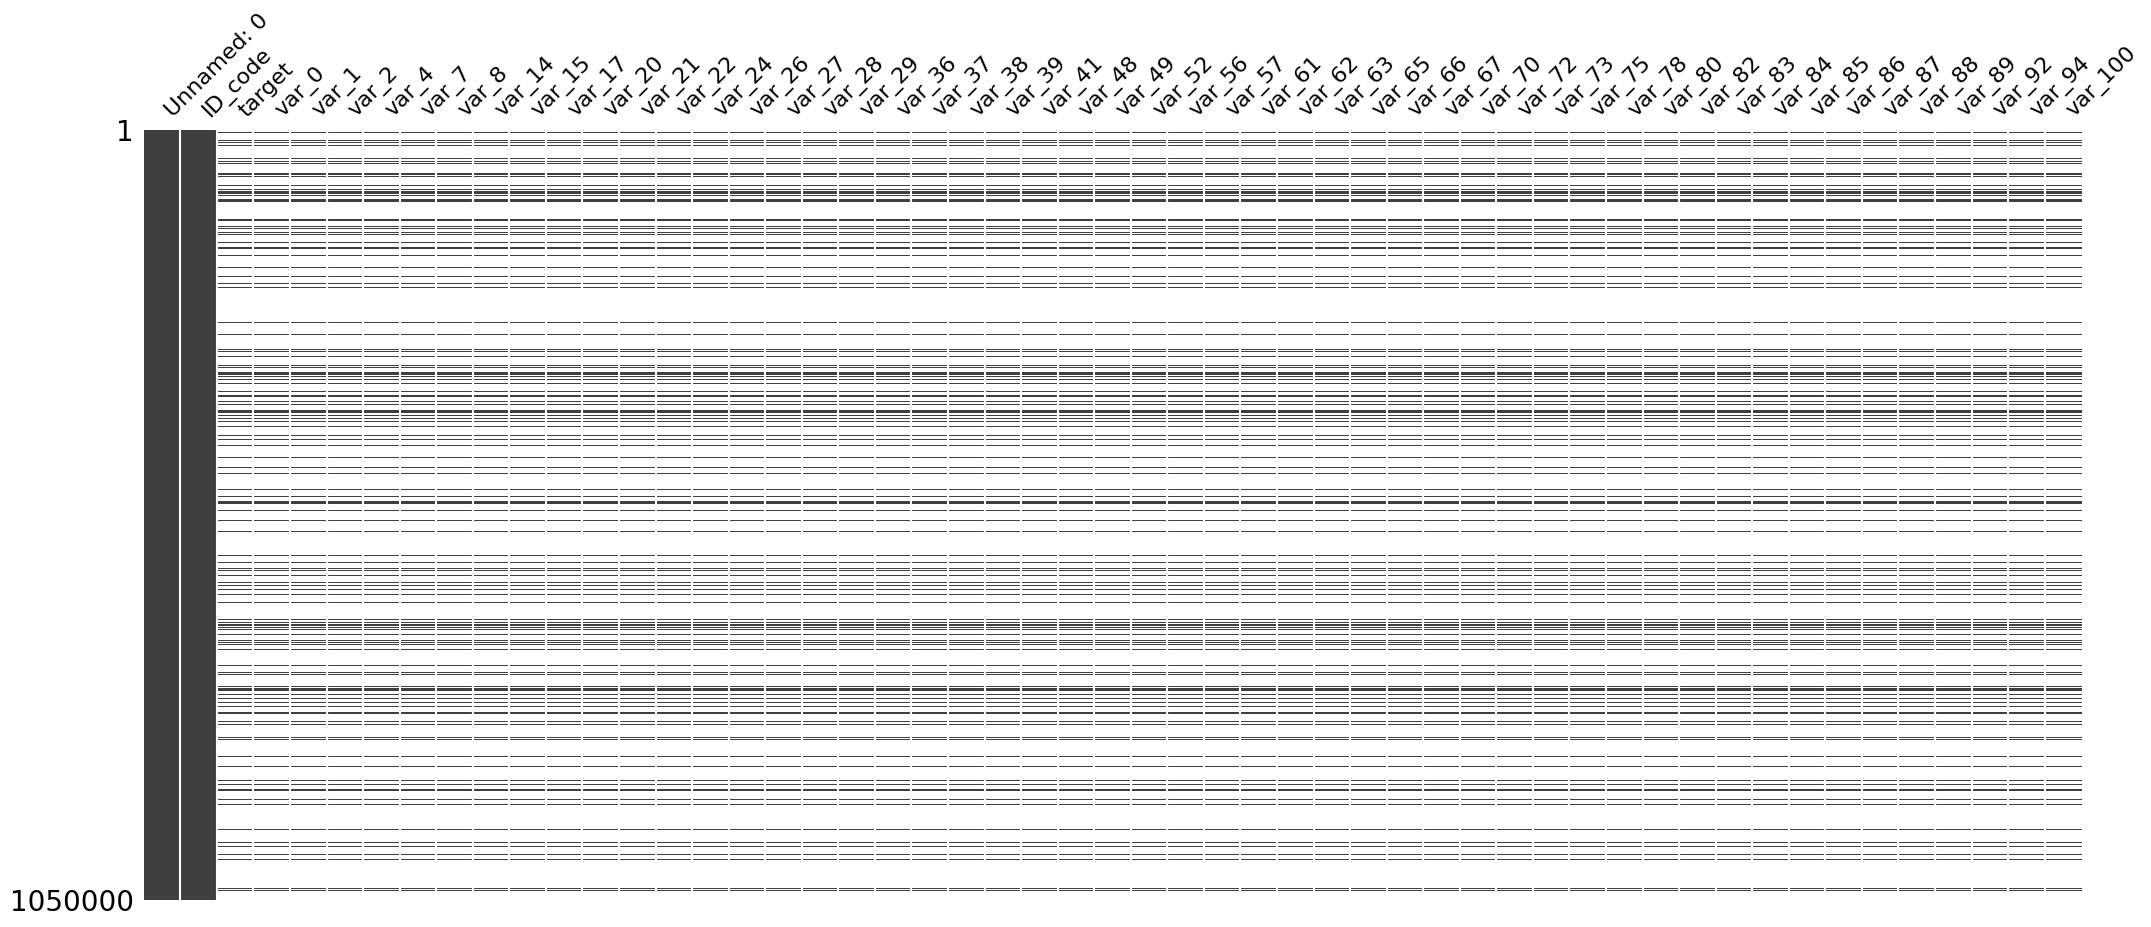

In [10]:
msno.matrix(df_cleaned, labels = True, sparkline=False)
plt.show()



---


### Drop entire row if target variable does not exist.

---



In [11]:
df_cleaned = df_cleaned.dropna(subset=["target"])


---
###Dropping  "Unnamed": 0 and "ID_code" columns
---

In [12]:
df_cleaned = df_cleaned.drop(columns=["Unnamed: 0", "ID_code"])



---

###Plot Missing values

---



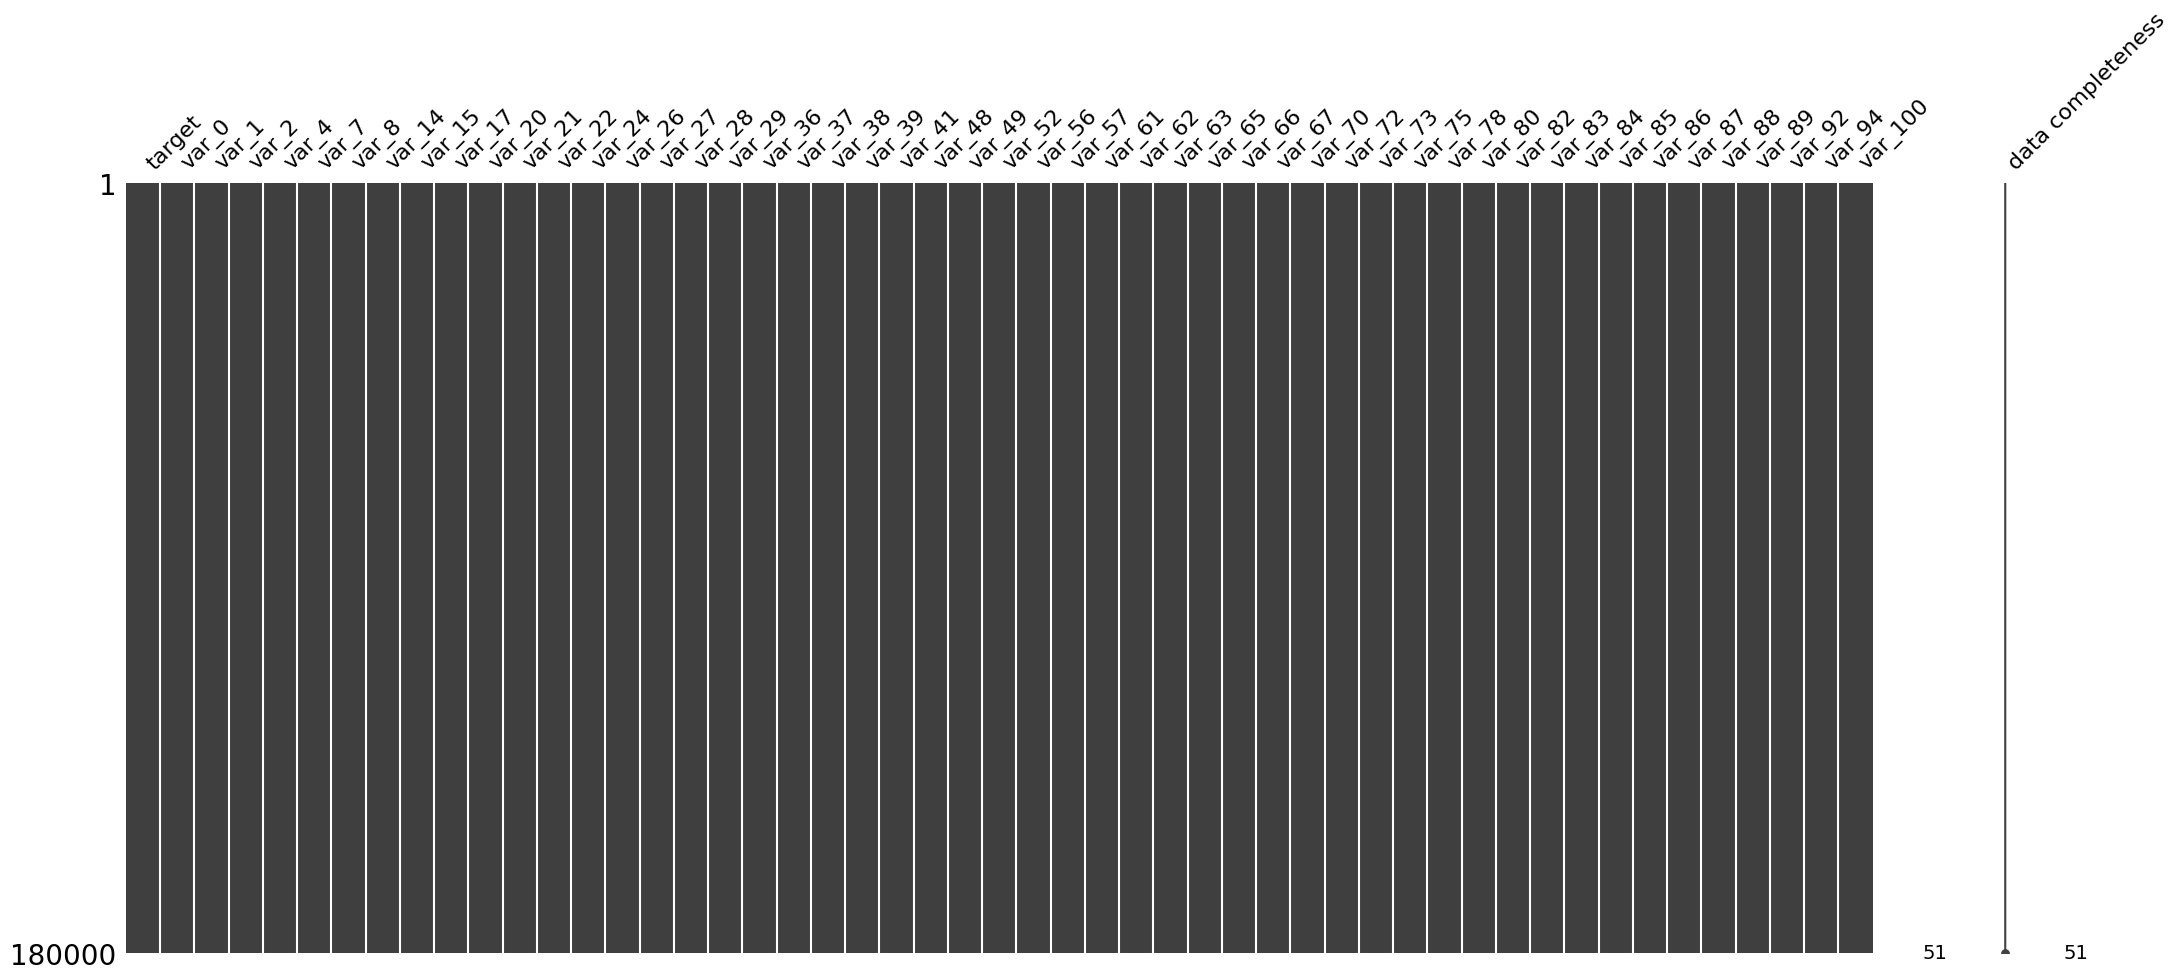

In [13]:
msno.matrix(df_cleaned, labels=True)
plt.show()



---

###Examine the shape of cleaned data

---



In [14]:
df_cleaned.shape

(180000, 51)



---

###Check for Null Values in df_cleaned

---



In [15]:
df_cleaned.info()
df_cleaned.isna().sum(axis=1).value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 180000 entries, 3 to 1049999
Data columns (total 51 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   target   180000 non-null  float64
 1   var_0    180000 non-null  float64
 2   var_1    180000 non-null  float64
 3   var_2    180000 non-null  float64
 4   var_4    180000 non-null  float64
 5   var_7    180000 non-null  float64
 6   var_8    180000 non-null  float64
 7   var_14   180000 non-null  float64
 8   var_15   180000 non-null  float64
 9   var_17   180000 non-null  float64
 10  var_20   180000 non-null  float64
 11  var_21   180000 non-null  float64
 12  var_22   180000 non-null  float64
 13  var_24   180000 non-null  float64
 14  var_26   180000 non-null  float64
 15  var_27   180000 non-null  float64
 16  var_28   180000 non-null  float64
 17  var_29   180000 non-null  float64
 18  var_36   180000 non-null  float64
 19  var_37   180000 non-null  float64
 20  var_38   180000 non-null  floa

,count
0,180000




---


### Describe the cleaned data set

---



In [16]:
df_cleaned.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
target,180000.0,0.100222,0.300297,0.0000,0.000000,0.00000,0.000000,1.0000
var_0,180000.0,7.440715,3.021636,-2.6917,5.160325,7.35095,9.511125,16.7165
var_1,180000.0,15.870166,3.010492,6.2993,13.830400,15.93460,18.061425,26.0791
var_2,180000.0,12.735619,4.185923,-1.0185,9.664675,12.67070,15.837300,26.9976
var_4,180000.0,-0.668334,5.968300,-22.7487,-4.997500,-0.56030,3.632525,18.8554
var_7,180000.0,1.190419,5.169343,-15.1940,-2.571400,1.19460,5.090450,18.4714
var_8,180000.0,6.813431,0.375564,5.3593,6.544100,6.80680,7.070900,8.3091
var_14,180000.0,11.946357,7.364523,-19.5443,6.756875,11.92530,17.039600,39.3968
var_15,180000.0,2.963064,0.369891,1.8512,2.698400,2.95990,3.241425,4.2204
var_17,180000.0,8.528080,4.641700,-6.0111,5.065750,8.59920,12.273300,22.3315


## Exploratory Data Analysis



---
### Plotting the distributions of all the variables. Results do show normally distributed features. Gaussian Naive Bayes assumes the predictors are normally distributed.

---




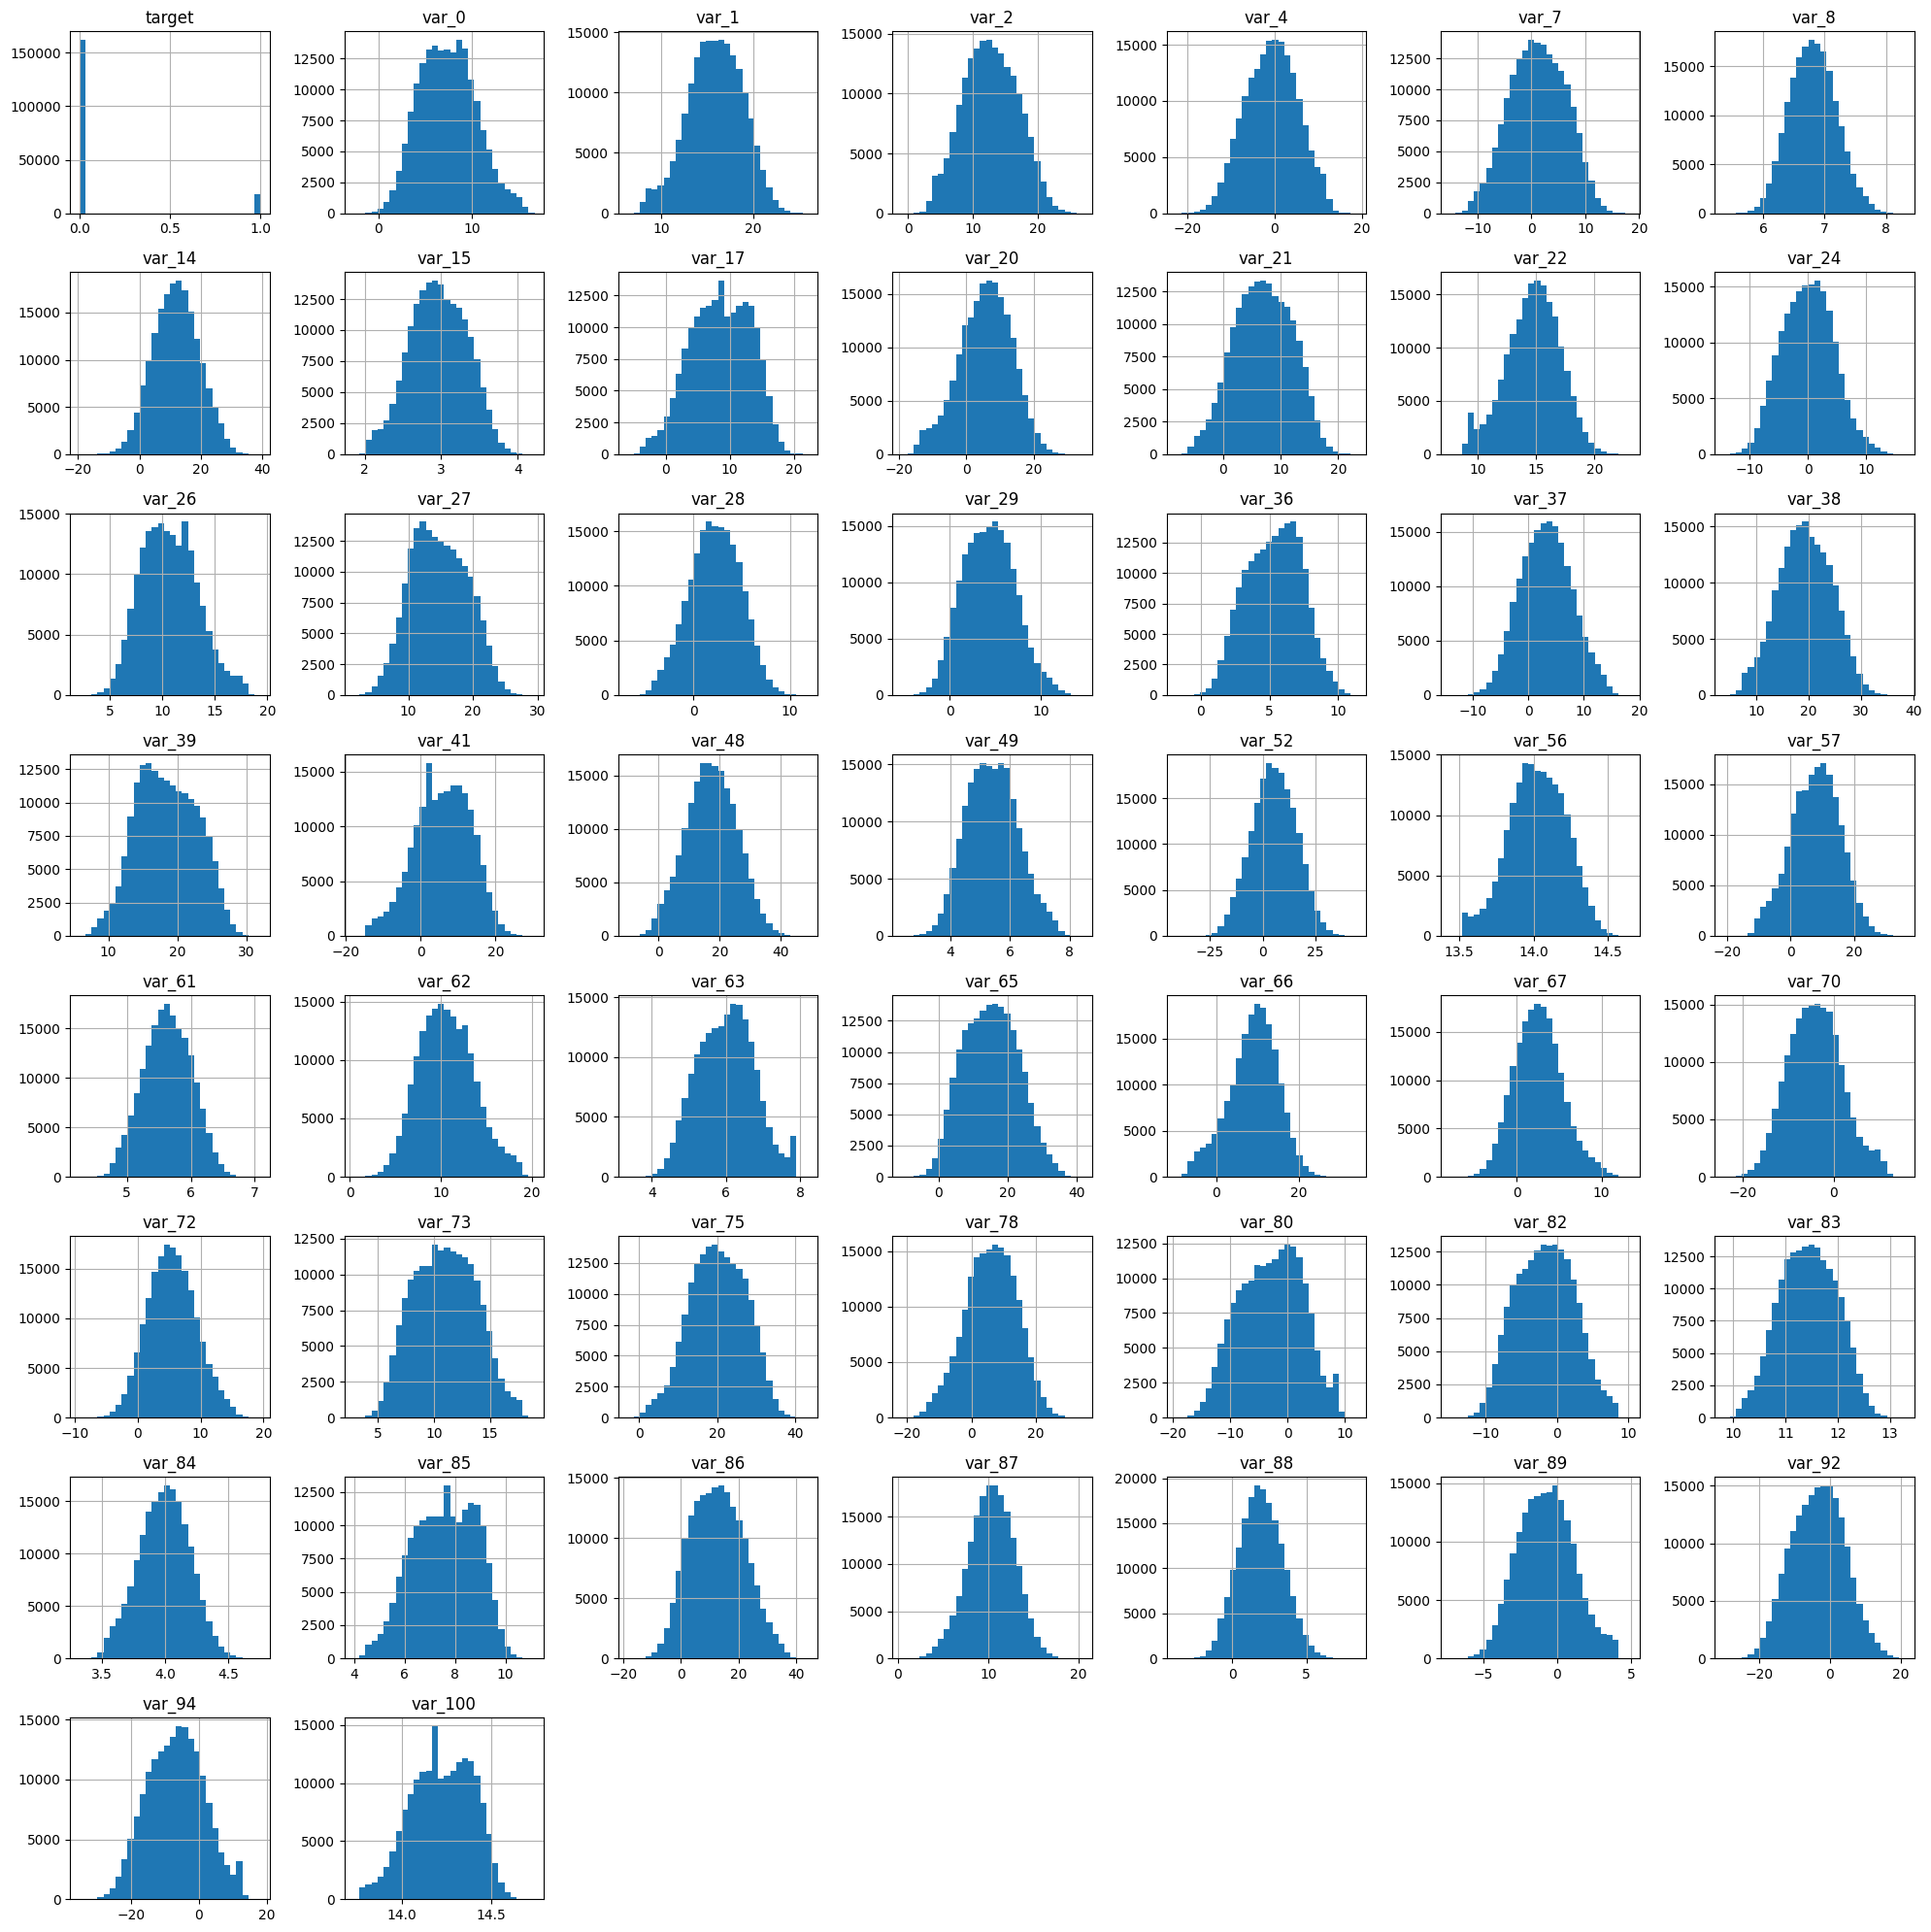

In [17]:
df_cleaned.hist(figsize=(20,20), bins=30)
plt.tight_layout()
#fig.savefig('all__cleaned_hist.png')

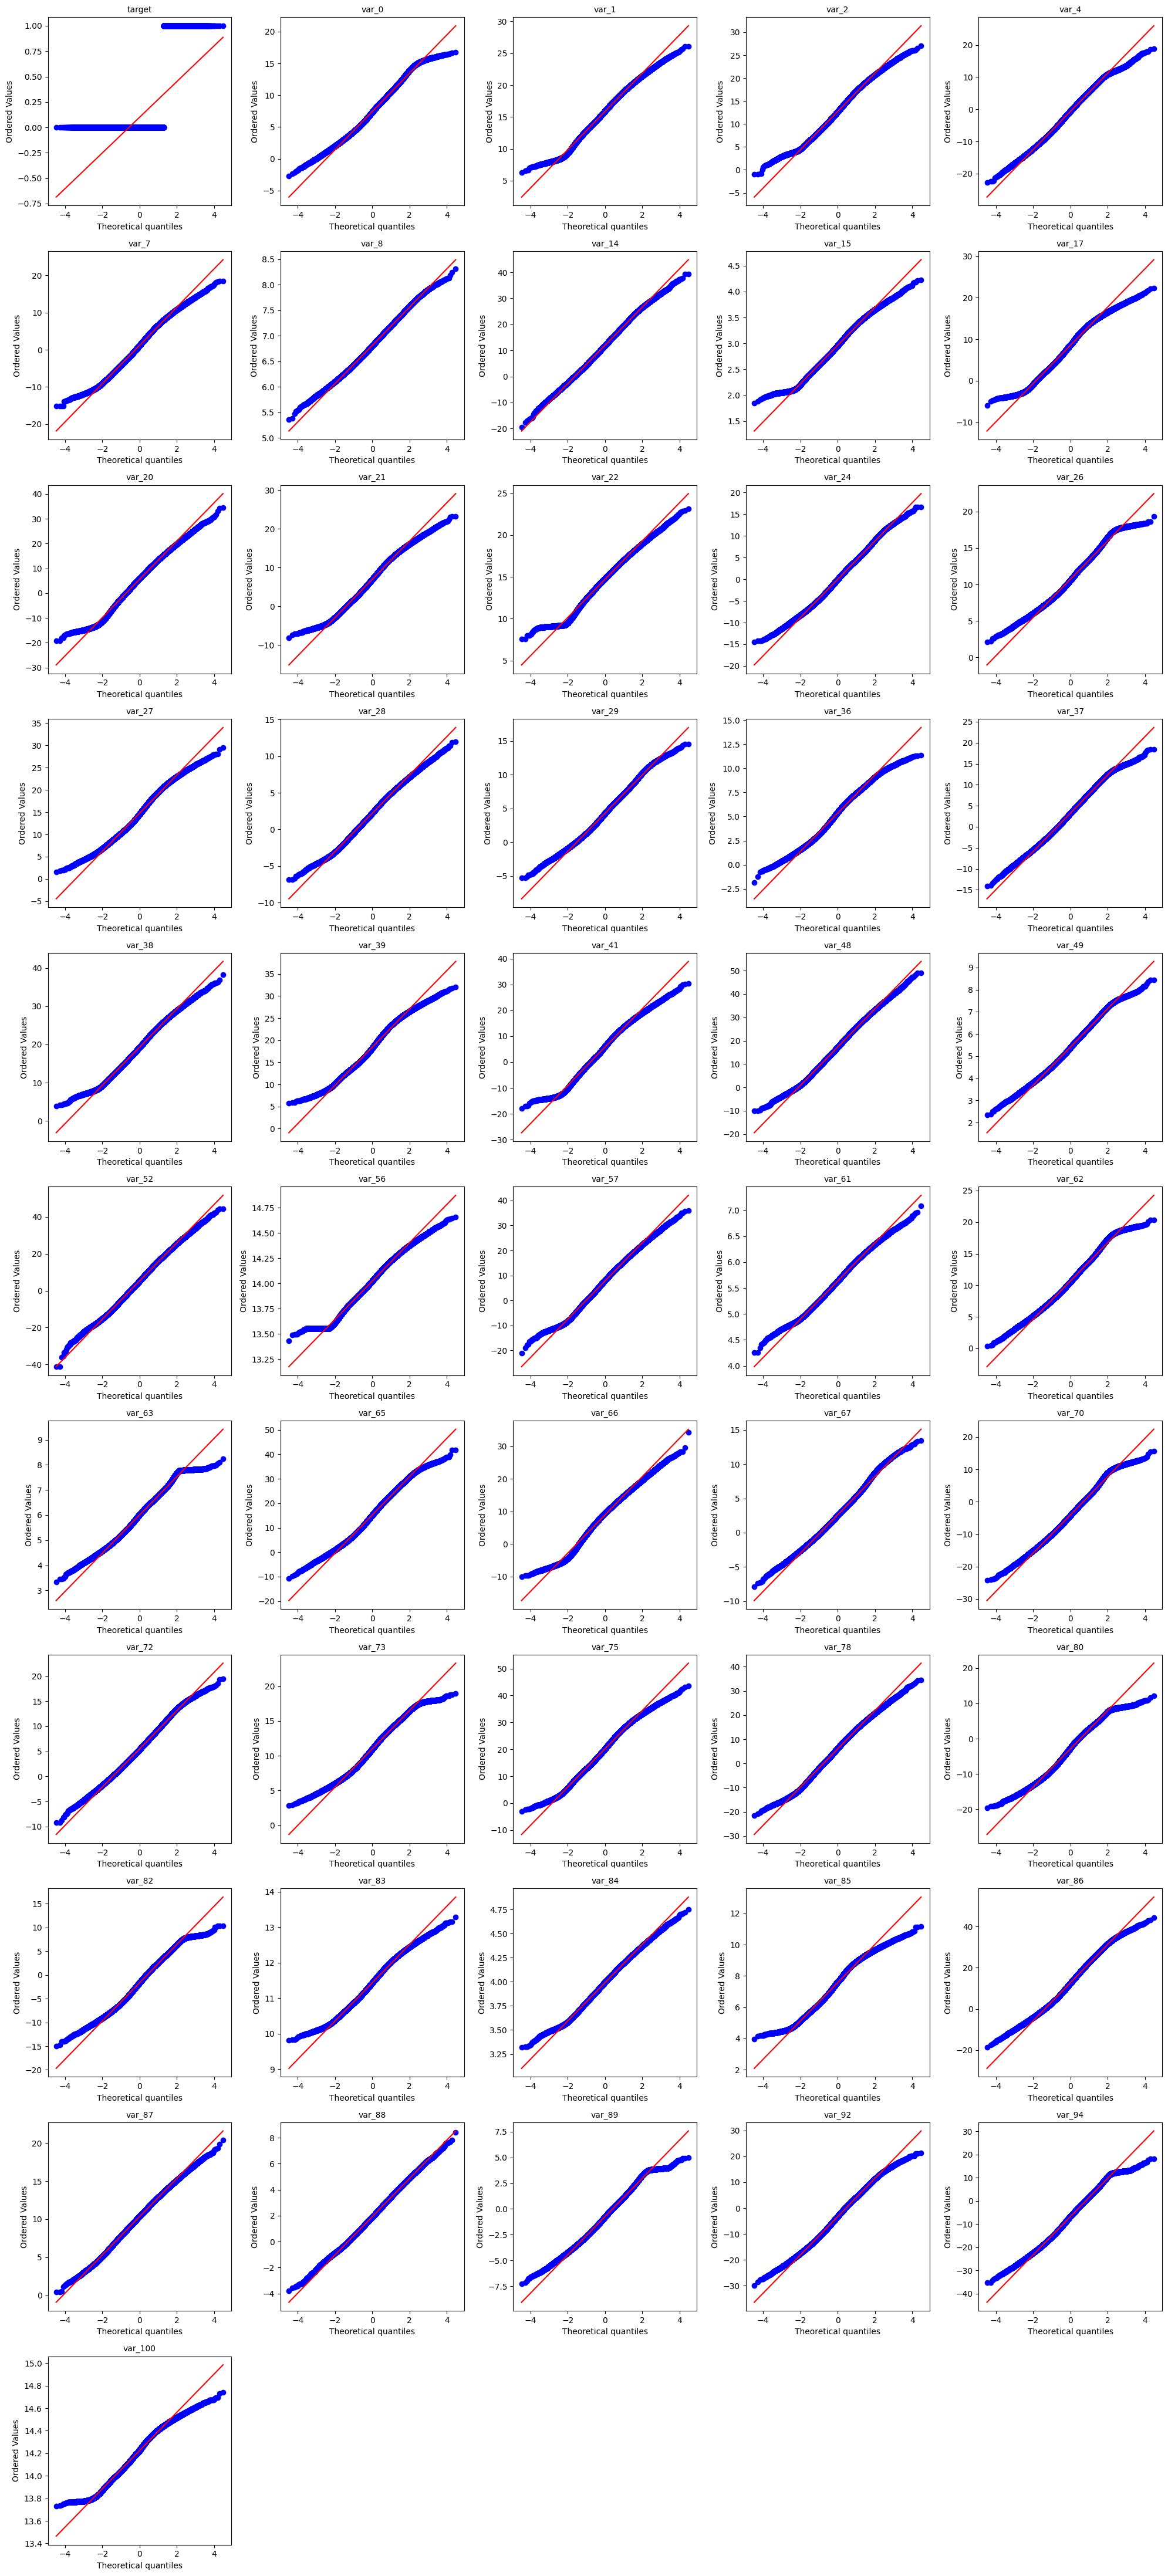

In [18]:

import matplotlib.pyplot as plt

# choose columns you want to plot
cols = df_cleaned.columns

# set number of columns in subplot grid
ncols = 5
nrows = math.ceil(len(cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    stats.probplot(df_cleaned[col], dist="norm", plot=axes[i])
    axes[i].set_title(col, fontsize=10)

# hide any extra empty subplots
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

---
### Verfied that the target only has 1s and 0s. We have a lot more "0"s and will need to balance the dataset later

---



In [19]:
df_cleaned['target'].value_counts()

,count
target,
0.0,161960
1.0,18040


___
### Plot target to help examine data for inbalances
___


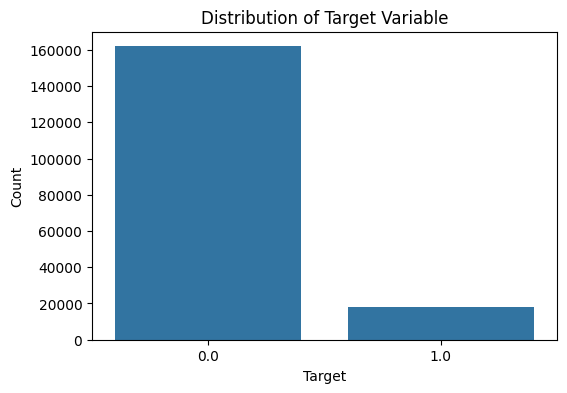

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x=df_cleaned["target"])

plt.xlabel("Target")
plt.ylabel("Count")
plt.title("Distribution of Target Variable")

plt.show()

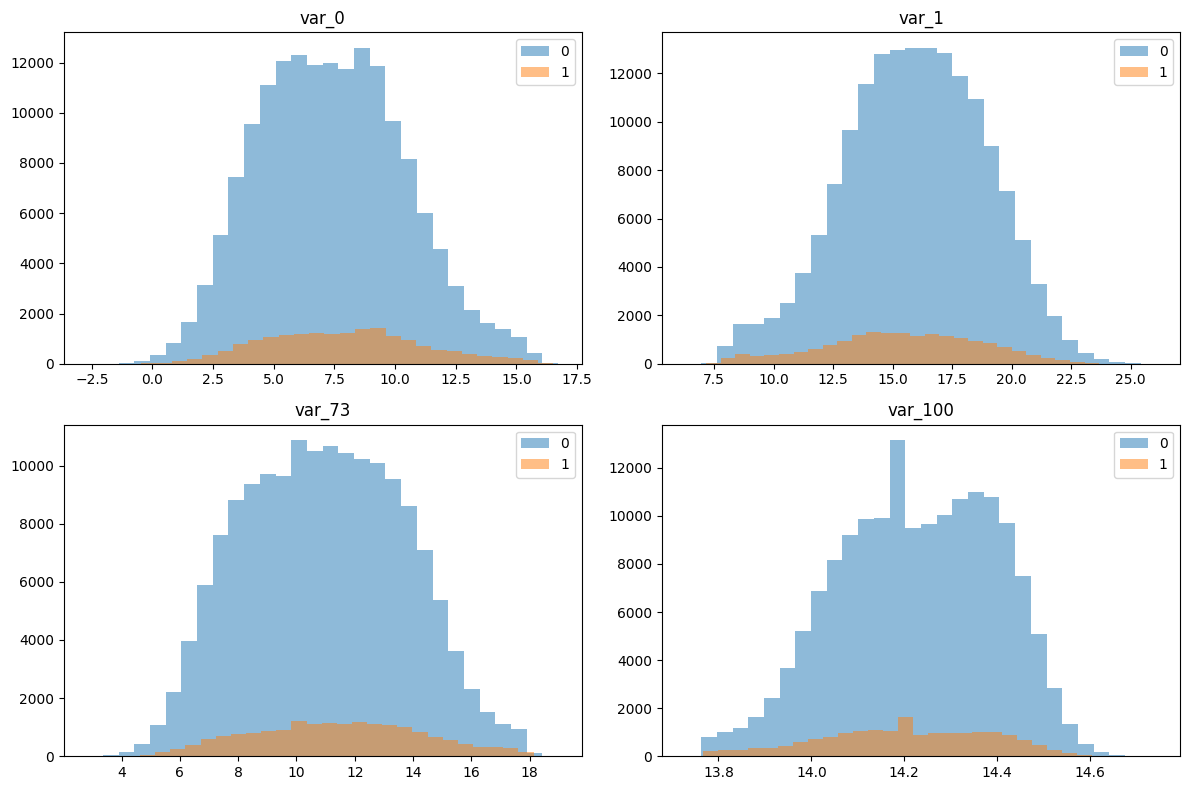

In [21]:
# Plotting a few a variables histograms by target

cols = ["var_0", "var_1", "var_73",'var_100']
plt.figure(figsize=(12,8))

for i, col in enumerate(cols):
    plt.subplot(2,2,i+1)

    plt.hist(df_cleaned[df_cleaned["target"]==0][col], bins=30, alpha=0.5, label="0")
    plt.hist(df_cleaned[df_cleaned["target"]==1][col], bins=30, alpha=0.5, label="1")

    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()



---

### Plot correlation values between all predictor columns to ensure there are no substantial correlations between predictors. This is important to support the decision to classify the ‘target’ using Naïve Bayes.

---



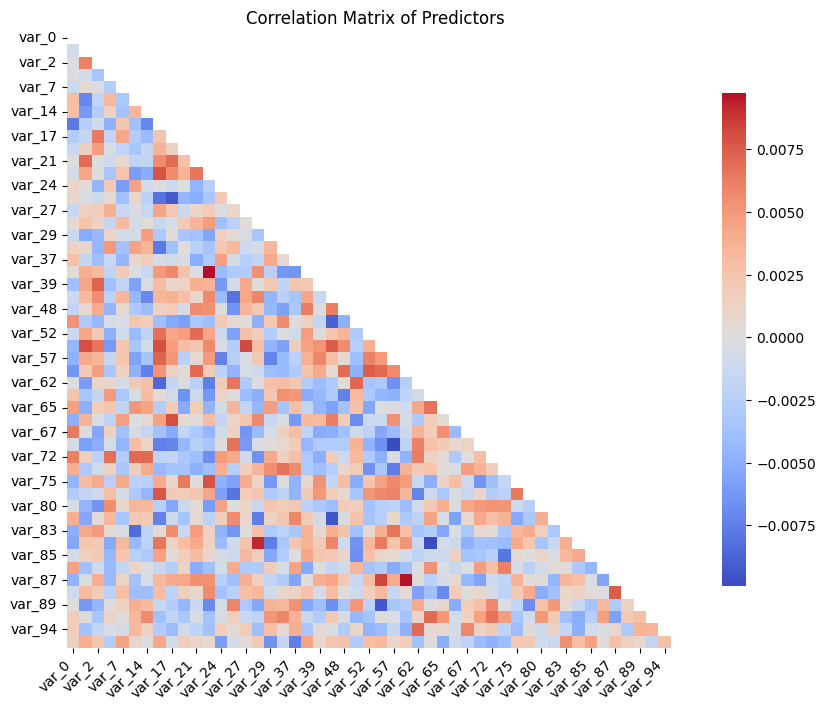

In [22]:
# Create predictor dataframe
predictors = df_cleaned.drop(columns=["target"]).copy()

# Compute correlation matrix
corr_matrix = predictors.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Predictors")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

In [23]:
# Unstack correlation matrix into pairs
corr_pairs = corr_matrix.unstack()

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Remove duplicate pairs (A,B) vs (B,A)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]

# Sort by absolute value (smallest first = least correlated)
least_corr = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=True).index)

# Show top least correlated pairs
least_corr.head(20)

,,0
var_86,var_88,-0.000009
var_15,var_24,-0.000018
var_36,var_75,0.000019
var_27,var_83,0.000021
var_73,var_89,0.000028
var_39,var_48,0.000030
var_38,var_87,-0.000032
var_26,var_80,-0.000033
var_0,var_62,-0.000037
var_78,var_85,-0.000039




---

### Create two data frames: one with all successful transactions, one with all unsuccessful transactions. Ensure they are copies. Display shape to determine how many went into each class

---



In [24]:
# copy of DataFrames for each class
df_success = df_cleaned[df_cleaned["target"] == 1].copy()
df_unsuccessful = df_cleaned[df_cleaned["target"] == 0].copy()

# Check the shape of each
print("Successful shape:", df_success.shape)
print("Unsuccessful shape:", df_unsuccessful.shape)

Successful shape: (18040, 51)
Unsuccessful shape: (161960, 51)


## Data Processing






---
### Define a Gaussian Naïve Bayes model using Sklearn.
---






In [25]:
model = GaussianNB()
model

GaussianNB()

---
### Divide the data frame into training and testing subsets.
---


In [26]:
# Separate features and target
X = df_cleaned.drop(columns=["target"])
y = df_cleaned["target"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Check shapes
X_train.shape, X_test.shape

((144000, 50), (36000, 50))


---

### Train the model using the training subset of the dataset.


---




In [27]:
model.fit(X_train,y_train)


GaussianNB()



---

###Test the model using the testing subset of the dataset. Calculate and report the accuracy.

---

In [28]:
# Determine Accuracy
y_pred = model.predict(X_test)
accuracy_full_dataset = (y_test - y_pred).abs().mul(-100).add(100).mean()
print(f'Accuracy of full data set: {accuracy_full_dataset} % ')

Accuracy of full data set: 91.09166666666667 % 


---
### Perform a cross-validation loop to calculate the accuracy of your model. Report that accuracy. How does it compare to the accuracy you calculated in #14?

---


In [29]:
n = 100
results = np.zeros(n)

for i in range(n):
    # 1. Random train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20
    )

    # 2. Initialize model
    gnb = GaussianNB()

    # 3. Train
    gnb.fit(X_train, y_train)

    # 4. Predict
    y_pred = gnb.predict(X_test)

    # 5. Accuracy (manual)
    results[i] = 1 - np.abs(y_test - y_pred).mean()

# View results
print("Mean accuracy:", results.mean())
print("Std deviation:", results.std())

Mean accuracy: 0.9112255555555556
Std deviation: 0.0013496529046250992



---
### Plotting a histogram of the accuracy scores generated in cross-validation loop.
---



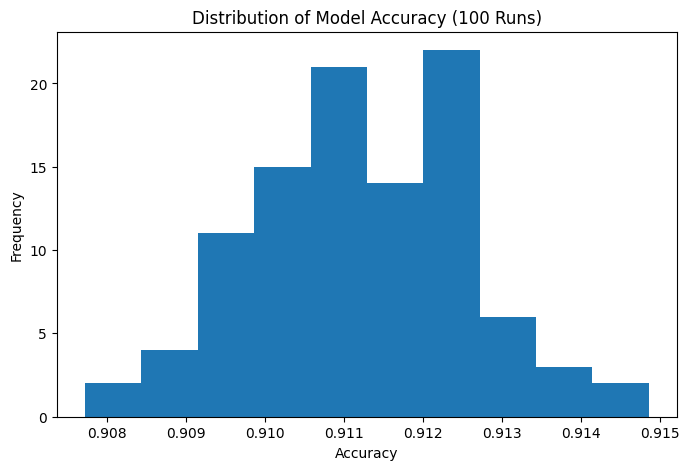

In [30]:
plt.figure(figsize=(8,5))
plt.hist(results, bins=10)

plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Distribution of Model Accuracy (100 Runs)")

plt.show()

---

The histogram shows the distribution of accuracy scores across 100 different train-test splits. The results are tightly clustered around ~91%, indicating that the model performs consistently regardless of how the data is partitioned.

---

---
### Confusion matrix from full dataset
---


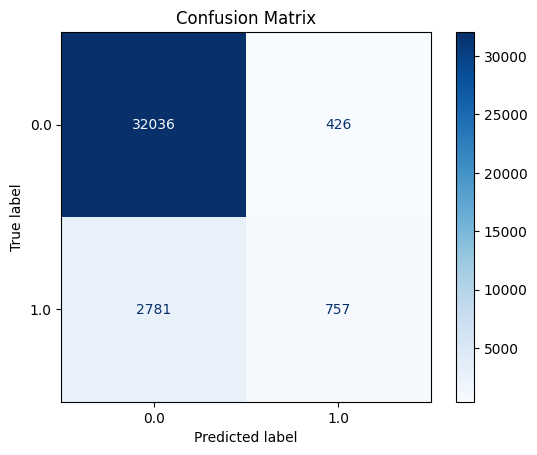

In [31]:
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize=None,
    values_format='d',
    cmap='Blues'
)

plt.grid(False)
plt.title('Confusion Matrix')
plt.show()


---
The confusion matrix reveals that the dataset is highly imbalanced, with significantly more samples belonging to class 0 than class 1. While the model performs very well in predicting class 0, it struggles to correctly identify class 1, as shown by the high number of false negatives.

As a result, accuracy alone may be misleading.

---



---
## Repeating the cross-validation process on a balanced data set
---

---
### Balancing the data set
---


In [32]:
# Downsample "target = 0" df
df_unsuccessful_sampled = df_unsuccessful.sample( n=len(df_success),random_state=42)

# Combine both classes
df_balanced = pd.concat([df_success, df_unsuccessful_sampled])

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42)

# Check balance
print(df_balanced["target"].value_counts())

target
1.0    18040
0.0    18040
Name: count, dtype: int64


---
####Dropping Target from balanced data frames
---

In [33]:
X_bal = df_balanced.drop(columns=["target"])
y_bal = df_balanced["target"]

---
#### Splitting the test and training set

---

In [34]:
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)

---
#### Initialize model + train
---

In [35]:
# Initialize model
model_bal = GaussianNB()

# Train
model_bal.fit(X_train_bal, y_train_bal)

GaussianNB()

---
#### Determine Accuracy of Balanced Data
---

In [36]:
# Determine Accuracy of Balanced Data Set
y_pred_bal = model_bal.predict(X_test_bal)
accuracy_full_dataset = (y_test_bal - y_pred_bal).abs().mul(-100).add(100).mean()
print(f'Accuracy of full data set: {accuracy_full_dataset} % ')

Accuracy of full data set: 75.41574279379158 % 


---
#### Perform CV test . Results = 75.39%
---

In [37]:
n = 100
results_bal = np.zeros(n)

for i in range(n):
    # 1. Train/test split (balanced data)
    X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
        X_bal, y_bal,
        test_size=0.20,
        stratify=y_bal
    )

    # 2. Model
    gnb = GaussianNB()

    # 3. Train
    gnb.fit(X_train_bal, y_train_bal)

    # 4. Predict
    y_pred_bal = gnb.predict(X_test_bal)

    # 5. Accuracy (manual)
    results_bal[i] = 1 - np.abs(y_test_bal - y_pred_bal).mean()

# Summary
print("Mean accuracy (balanced):", results_bal.mean())
print("Std deviation (balanced):", results_bal.std())

Mean accuracy (balanced): 0.7535961751662973
Std deviation (balanced): 0.0043101287430924295


---
####Plot histogram from CV
---

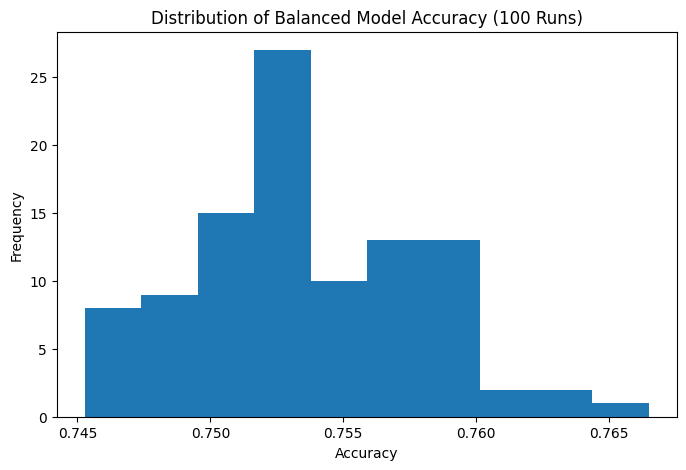

In [38]:
plt.figure(figsize=(8,5))
plt.hist(results_bal, bins=10)

plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Distribution of Balanced Model Accuracy (100 Runs)")

plt.show()

---
#### Display Confusion Matrix
---

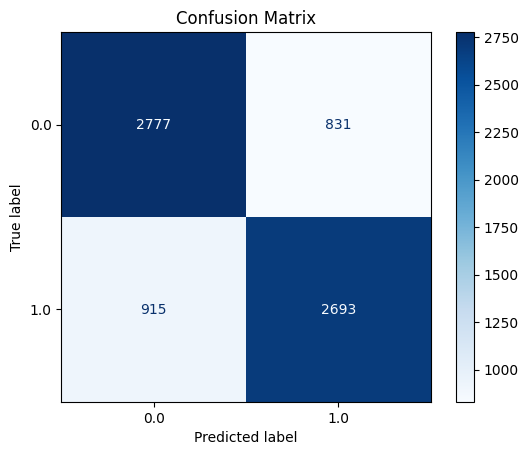

In [39]:
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test_bal,
    y_pred_bal,
    normalize=None,
    values_format='d',
    cmap='Blues'
)

plt.grid(False)
plt.title('Confusion Matrix')
plt.show()

### Confusion Matrix (Balanced Dataset)

The balanced dataset results in a more symmetric confusion matrix, with improved detection of the minority class (target = 1). True positives have increased significantly, indicating better recall for successful transactions.

This improvement comes with an increase in false positives, highlighting the trade-off between precision and recall. However, the model is now less biased toward the majority class and provides a more meaningful classification across both classes.

## Data Visualization


#### Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report)

---



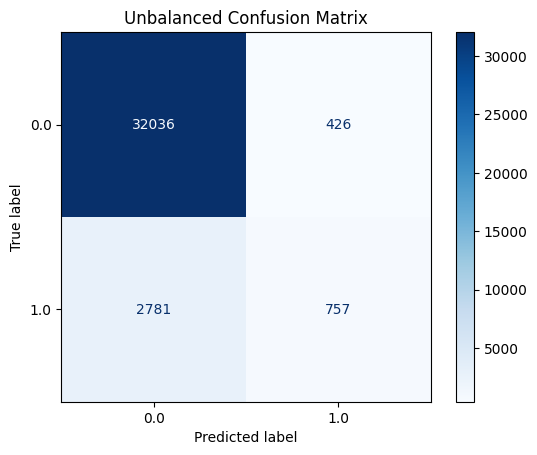

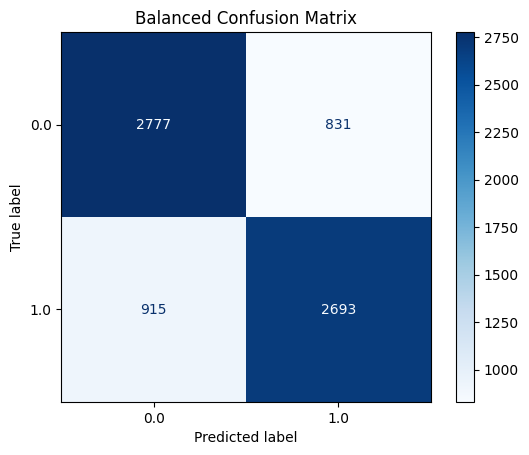

In [40]:
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize=None,
    values_format='d',
    cmap='Blues'
)

plt.grid(False)
plt.title('Unbalanced Confusion Matrix')
plt.show()


metrics.ConfusionMatrixDisplay.from_predictions(
    y_test_bal,
    y_pred_bal,
    normalize=None,
    values_format='d',
    cmap='Blues'
)

plt.grid(False)
plt.title('Balanced Confusion Matrix')
plt.show()



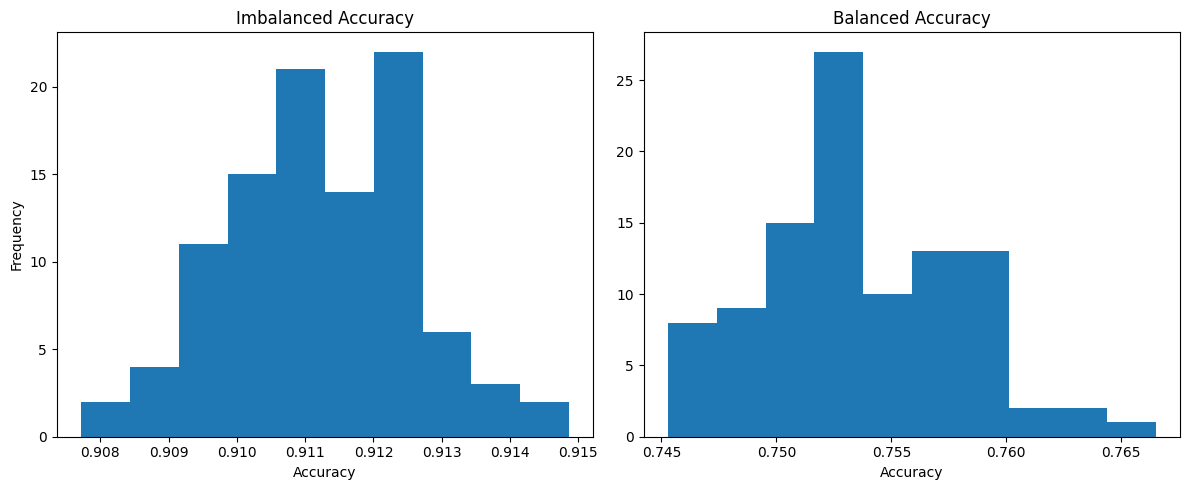

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original
axes[0].hist(results, bins=10)
axes[0].set_title("Imbalanced Accuracy")
axes[0].set_xlabel("Accuracy")
axes[0].set_ylabel("Frequency")

# Balanced
axes[1].hist(results_bal, bins=10)
axes[1].set_title("Balanced Accuracy")
axes[1].set_xlabel("Accuracy")

plt.tight_layout()
plt.show()

## Results




### Communication of the Results

- The initial model trained on the imbalanced dataset achieved high accuracy (~91%)
- However, this performance was largely driven by the majority class (target = 0)
- The confusion matrix showed that the model struggled to correctly identify successful transactions (target = 1), resulting in many false negatives

- After balancing the dataset to a 50/50 class distribution, overall accuracy decreased
- Despite this, the model’s ability to detect successful transactions improved significantly
- The confusion matrix became more symmetric, indicating more balanced performance across both classes

- This highlights a key trade-off between accuracy and meaningful classification performance
- High accuracy in imbalanced datasets can be misleading if the model ignores the minority class

- Overall, balancing the dataset led to a more reliable and useful model for identifying successful transactions
- This demonstrates the importance of evaluating models using multiple metrics, not just accuracy

### Next Steps

- Perform feature selection to evaluate whether reducing the number of predictors improves model performance and reduces noise

- Evaluate the performance of Gaussian Naive Bayes across different feature subsets to understand how feature combinations impact results

- Analyze misclassifications (false positives and false negatives) to identify patterns the model is failing to capture

- Validate results using cross-validation to ensure the model generalizes well to unseen data

### Experimenting with looking at FN / FP in individual variables

In [42]:
# build evaluation dataframe
df_eval_bal = X_test_bal.copy()
df_eval_bal["y_true"] = y_test_bal.values
df_eval_bal["y_pred"] = y_pred_bal

# label error type
df_eval_bal["error_type"] = "correct"
df_eval_bal.loc[(df_eval_bal["y_true"] == 0) & (df_eval_bal["y_pred"] == 1), "error_type"] = "fp"
df_eval_bal.loc[(df_eval_bal["y_true"] == 1) & (df_eval_bal["y_pred"] == 0), "error_type"] = "fn"

# check result
print(df_eval_bal["error_type"].value_counts())
df_eval_bal.head()

error_type
correct    5470
fn          915
fp          831
Name: count, dtype: int64


,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_86,var_87,var_88,var_89,var_92,var_94,var_100,y_true,y_pred,error_type
789545,2.8026,12.8974,13.9768,-4.4945,3.6549,7.1024,12.7368,2.1087,6.0565,7.8693,...,23.1415,11.3690,5.0054,-1.4272,-3.6085,-3.2114,14.2009,0.0,1.0,fp
1017869,8.4087,18.5327,15.7743,-3.8194,7.6231,6.6256,5.1693,2.9964,2.6024,14.2865,...,2.1576,13.3307,1.5057,-3.9218,-4.2911,-3.6869,14.1918,0.0,0.0,correct
697066,12.4263,16.8776,9.4694,-3.7437,8.9852,7.1435,0.7907,2.3342,2.8125,10.9003,...,20.2694,11.9013,4.7737,-0.0549,-10.1429,-2.8167,14.0308,0.0,1.0,fp
765150,1.5515,15.0521,15.4299,6.5695,0.4903,6.6847,6.7114,3.7250,15.0162,-4.7928,...,1.8942,5.6935,2.5748,-0.8367,-0.0150,-13.5183,14.3260,0.0,0.0,correct
113993,9.0337,15.6373,10.8976,-0.4335,3.7826,7.0439,12.4013,2.2042,-1.9683,14.1823,...,-2.0129,8.9061,-1.1397,2.6909,0.8346,1.6665,14.2028,1.0,1.0,correct


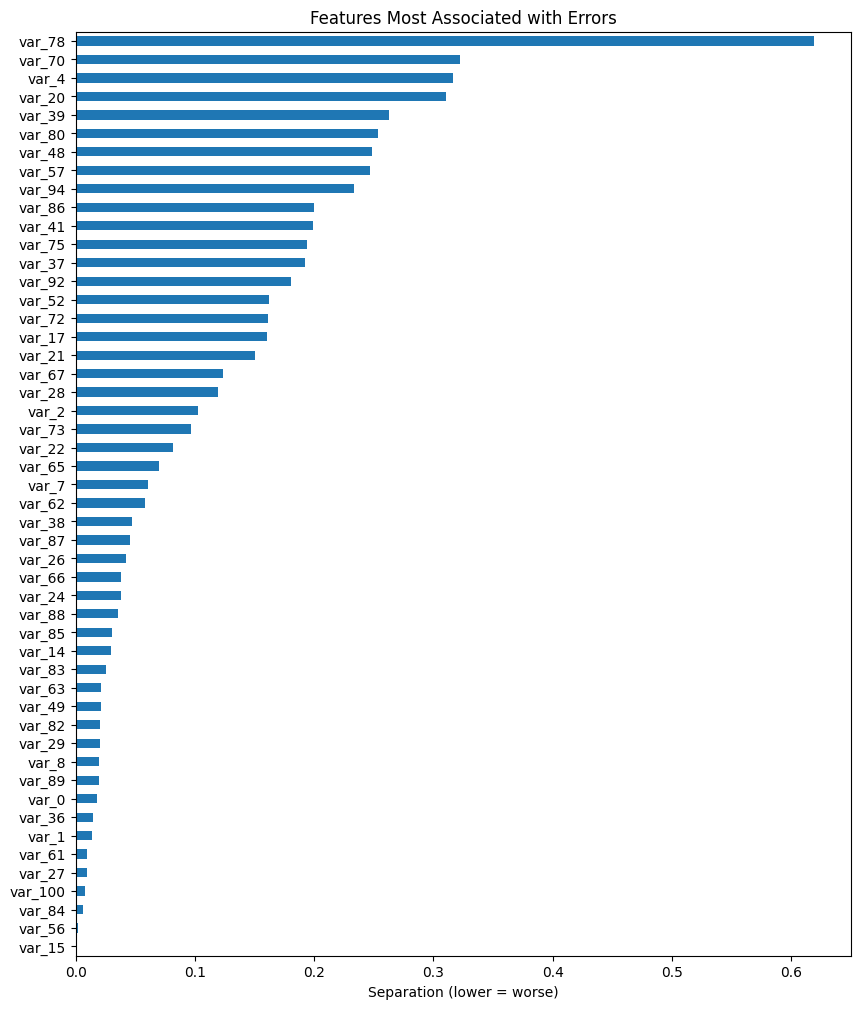

In [43]:
failure_scores = {}

for col in X.columns:
    correct = df_eval_bal[df_eval_bal.error_type == "correct"][col]
    errors = df_eval_bal[df_eval_bal.error_type != "correct"][col]

    failure_scores[col] = abs(correct.mean() - errors.mean())


pd.Series(failure_scores).sort_values().plot(
    kind='barh',
    figsize=(10, 12)
)

plt.title("Features Most Associated with Errors")
plt.xlabel("Separation (lower = worse)")
plt.show()

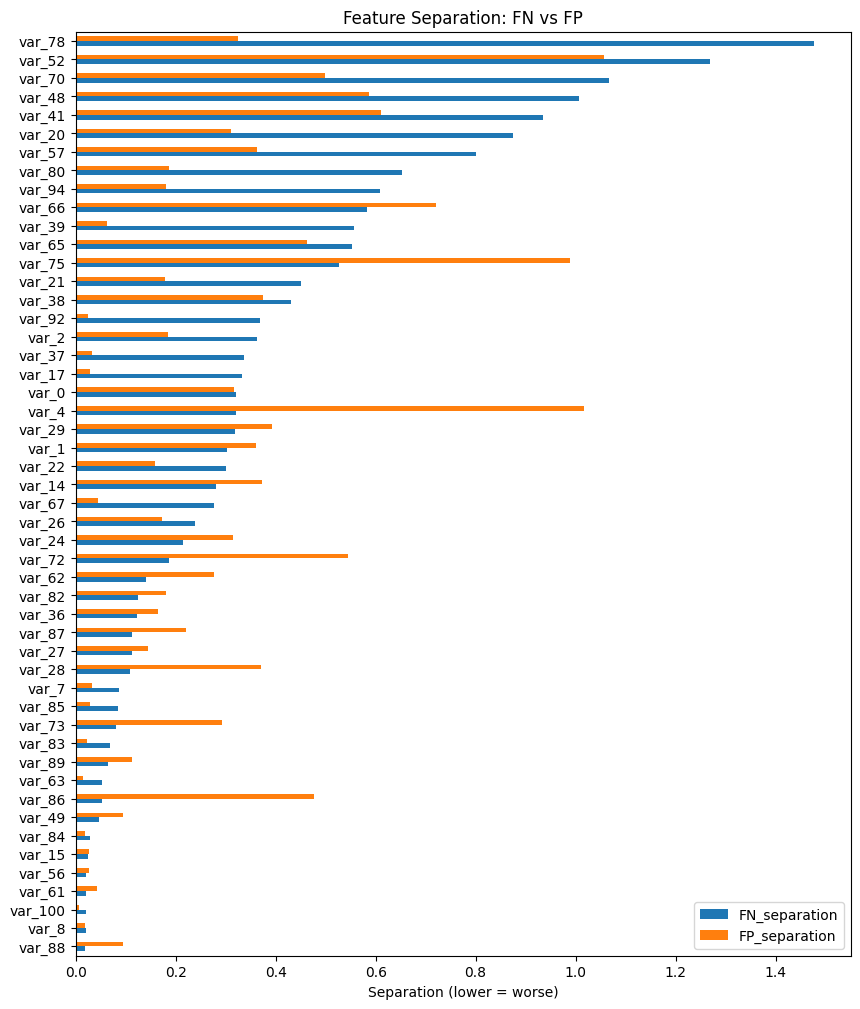

In [44]:
failure_fn = {}
failure_fp = {}

for col in X.columns:
    correct = df_eval_bal[df_eval_bal.error_type == "correct"][col]
    fn = df_eval_bal[df_eval_bal.error_type == "fn"][col]
    fp = df_eval_bal[df_eval_bal.error_type == "fp"][col]

    # Handle empty cases safely
    if len(fn) > 0:
        failure_fn[col] = abs(correct.mean() - fn.mean())
    else:
        failure_fn[col] = 0

    if len(fp) > 0:
        failure_fp[col] = abs(correct.mean() - fp.mean())
    else:
        failure_fp[col] = 0


failure_df = pd.DataFrame({
    "FN_separation": failure_fn,
    "FP_separation": failure_fp
})

# Sort by worst FN (you can change this)
failure_df = failure_df.sort_values(by="FN_separation")

# Plot
failure_df.plot(kind='barh', figsize=(10, 12))

plt.title("Feature Separation: FN vs FP")
plt.xlabel("Separation (lower = worse)")
plt.show()